# 07 — Least squares as projection

## Purpose

This notebook answers one question:

> Why is least squares a projection problem?

We will use the linear-algebra view first, then connect it back to line fitting.

The key idea is:

> When $\mathbf{b}$ cannot be reached exactly by $A\mathbf{x}$, least squares replaces $\mathbf{b}$ with the closest reachable vector.

That closest reachable vector is a projection.

## Imports and plotting helpers

The maths in this notebook is small enough to calculate by hand, but NumPy lets us check the ideas directly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

In [2]:
def print_vector(name, vector):
    # Print a vector in a compact notebook-friendly format.
    values = ", ".join(f"{value: .3f}" for value in vector)
    print(f"{name} = [{values}]")


def draw_vector_3d(ax, start, vector, label, text_offset=(0.04, 0.04, 0.04), **kwargs):
    # Draw a 3D vector as an arrow, then place a label near its tip.
    start = np.asarray(start, dtype=float)
    vector = np.asarray(vector, dtype=float)
    end = start + vector

    ax.quiver(
        start[0], start[1], start[2],
        vector[0], vector[1], vector[2],
        arrow_length_ratio=0.08,
        linewidth=2,
        **kwargs
    )

    ax.text(
        end[0] + text_offset[0],
        end[1] + text_offset[1],
        end[2] + text_offset[2],
        label,
        fontsize=11
    )


def setup_3d_axis(ax, title):
    # Use consistent, compact 3D axis settings for this notebook.
    ax.set_title(title)
    ax.set_xlabel("first coordinate")
    ax.set_ylabel("second coordinate")
    ax.set_zlabel("third coordinate")
    ax.set_xlim(0, 4.2)
    ax.set_ylim(0, 3.2)
    ax.set_zlim(0, 5.0)
    ax.view_init(elev=23, azim=-60)

## Quick recap: what projection does

Projection finds the closest reachable vector in a chosen direction or space.

For example, if we project an object vector $\mathbf{a}$ onto a target vector $\mathbf{b}$, the vector projection is:

$$
\operatorname{proj}_{\mathbf{b}}(\mathbf{a})
=
\frac{\mathbf{a} \cdot \mathbf{b}}{\mathbf{b} \cdot \mathbf{b}}
\mathbf{b}
$$

That projection is the part of $\mathbf{a}$ that lies in the direction of $\mathbf{b}$.

The leftover part is:

$$
\mathbf{a} - \operatorname{proj}_{\mathbf{b}}(\mathbf{a})
$$

and it is perpendicular to the target direction.

Together, the projection and leftover reconstruct the original vector:

$$
\mathbf{a}
=
\operatorname{proj}_{\mathbf{b}}(\mathbf{a})
+
\left(
\mathbf{a} - \operatorname{proj}_{\mathbf{b}}(\mathbf{a})
\right)
$$

The same idea works for a whole line, plane, or higher-dimensional flat space:

> projection means the closest point in the space we are allowed to use.

## Start with a linear system

A linear system is often written as:

$$
A\mathbf{x} = \mathbf{b}
$$

Here:

- $A$ is a matrix
- $\mathbf{x}$ is a vector of unknowns
- $\mathbf{b}$ is the vector we are trying to reach

The important reading is this:

> $A\mathbf{x}$ is a linear combination of the columns of $A$.

Suppose $A$ has two columns, $\mathbf{a}_1$ and $\mathbf{a}_2$:

$$
A =
\begin{bmatrix}
| & | \\
\mathbf{a}_1 & \mathbf{a}_2 \\
| & |
\end{bmatrix}
$$

Then:

$$
A
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
=
x_1\mathbf{a}_1 + x_2\mathbf{a}_2
$$

So solving $A\mathbf{x} = \mathbf{b}$ means:

> Can I combine the columns of $A$ to exactly make $\mathbf{b}$?

In [3]:
# A has two columns.
#
# Each column is a vector in 3D space.
# A @ x means: combine those two column vectors using the numbers in x.

A = np.array([
    [1, 0],
    [0, 1],
    [1, 1]
])

a1 = A[:, 0]
a2 = A[:, 1]

x_trial = np.array([2, 1])

Ax_trial = A @ x_trial

print_vector("a1", a1)
print_vector("a2", a2)
print()
print_vector("x_trial", x_trial)
print_vector("A @ x_trial", Ax_trial)

a1 = [ 1.000,  0.000,  1.000]
a2 = [ 0.000,  1.000,  1.000]

x_trial = [ 2.000,  1.000]
A @ x_trial = [ 2.000,  1.000,  3.000]


The trial vector is:

$$
\mathbf{x}_{\text{trial}}
=
\begin{bmatrix}
2 \\
1
\end{bmatrix}
$$

So $A\mathbf{x}_{\text{trial}}$ means:

$$
2\mathbf{a}_1 + 1\mathbf{a}_2
$$

Using the columns above:

$$
2
\begin{bmatrix}
1 \\
0 \\
1
\end{bmatrix}
+
1
\begin{bmatrix}
0 \\
1 \\
1
\end{bmatrix}
=
\begin{bmatrix}
2 \\
1 \\
3
\end{bmatrix}
$$

## Column space

The **column space** of a matrix is the set of all vectors we can make by combining its columns.

For this matrix:

$$
A =
\begin{bmatrix}
1 & 0 \\
0 & 1 \\
1 & 1
\end{bmatrix}
$$

every vector $A\mathbf{x}$ has this form:

$$
A
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
=
x_1
\begin{bmatrix}
1 \\
0 \\
1
\end{bmatrix}
+
x_2
\begin{bmatrix}
0 \\
1 \\
1
\end{bmatrix}
=
\begin{bmatrix}
x_1 \\
x_2 \\
x_1 + x_2
\end{bmatrix}
$$

So every reachable vector has third coordinate equal to:

$$
\text{first coordinate} + \text{second coordinate}
$$

In this example, the column space is a plane in 3D space.

We write it as $C(A)$.

In [4]:
# Let's generate a small grid of reachable vectors.
#
# Each reachable vector has the form:
#
#     A @ [x1, x2]
#
# which equals:
#
#     [x1, x2, x1 + x2]

x1_values = np.linspace(0, 3, 4)
x2_values = np.linspace(0, 2, 3)

reachable_vectors = []

for x1 in x1_values:
    for x2 in x2_values:
        x = np.array([x1, x2])
        reachable_vectors.append(A @ x)

reachable_vectors = np.array(reachable_vectors)

reachable_vectors[:5]

array([[0., 0., 0.],
       [0., 1., 1.],
       [0., 2., 2.],
       [1., 0., 1.],
       [1., 1., 2.]])

The specific grid is not important.

The important point is that changing $\mathbf{x}$ moves us around inside the column space of $A$.

It cannot take us outside that space.

## When there is no exact solution

Now choose a target vector:

$$
\mathbf{b}
=
\begin{bmatrix}
2 \\
1 \\
4
\end{bmatrix}
$$

The question $A\mathbf{x} = \mathbf{b}$ asks:

> Can we combine the columns of $A$ to exactly make $\mathbf{b}$?

But every vector in $C(A)$ has this form:

$$
\begin{bmatrix}
x_1 \\
x_2 \\
x_1 + x_2
\end{bmatrix}
$$

To match the first two coordinates of $\mathbf{b}$, we would need:

$$
x_1 = 2
\qquad
x_2 = 1
$$

That would force the third coordinate to be:

$$
x_1 + x_2 = 3
$$

But $\mathbf{b}$ has third coordinate $4$.

So $\mathbf{b}$ is not in $C(A)$, and the exact system has no solution.

In [5]:
b = np.array([2, 1, 4])

# If we match the first two coordinates exactly, we would choose:
x_match_first_two = np.array([2, 1])

# But that does not match the third coordinate.
attempt = A @ x_match_first_two
residual_attempt = b - attempt

print_vector("b", b)
print_vector("A @ [2, 1]", attempt)
print_vector("b - A @ [2, 1]", residual_attempt)

b = [ 2.000,  1.000,  4.000]
A @ [2, 1] = [ 2.000,  1.000,  3.000]
b - A @ [2, 1] = [ 0.000,  0.000,  1.000]


The residual is the miss, or leftover:

$$
\mathbf{r} = \mathbf{b} - A\mathbf{x}
$$

For the trial $\mathbf{x} = [2, 1]$, the miss is:

$$
\begin{bmatrix}
2 \\
1 \\
4
\end{bmatrix}
-
\begin{bmatrix}
2 \\
1 \\
3
\end{bmatrix}
=
\begin{bmatrix}
0 \\
0 \\
1
\end{bmatrix}
$$

That is not the smallest possible miss. It is just an easy first attempt.

## Least squares changes the question

If $A\mathbf{x} = \mathbf{b}$ has no exact solution, we cannot make the residual zero.

So we change the question.

Instead of asking:

> Which $\mathbf{x}$ makes $A\mathbf{x}$ exactly equal to $\mathbf{b}$?

we ask:

> Which $\mathbf{x}^{*}$ makes $A\mathbf{x}^{*}$ as close as possible to $\mathbf{b}$?

That is the least-squares problem:

$$
\mathbf{x}^{*}
=
\underset{\mathbf{x}}{\operatorname{argmin}}
\left\lVert
\mathbf{b} - A\mathbf{x}
\right\rVert^2
$$

The name comes from the squared length of the residual:

$$
\left\lVert
\mathbf{b} - A\mathbf{x}
\right\rVert^2
=
(b_1 - v_1)^2 + (b_2 - v_2)^2 + \cdots + (b_n - v_n)^2
$$

where $\mathbf{v} = A\mathbf{x}$.

In [6]:
# np.linalg.lstsq finds the least-squares solution.
#
# It returns the x_star that makes A @ x_star as close as possible to b.
# The exact system has no solution, but the least-squares problem does.

x_star, residuals, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)

v = A @ x_star
r = b - v

print_vector("x_star", x_star)
print_vector("v = A @ x_star", v)
print_vector("r = b - v", r)
print()
print(f"distance from b to v = {np.linalg.norm(r):.3f}")
print(f"squared distance = {np.linalg.norm(r) ** 2:.3f}")

x_star = [ 2.333,  1.333]
v = A @ x_star = [ 2.333,  1.333,  3.667]
r = b - v = [-0.333, -0.333,  0.333]

distance from b to v = 0.577
squared distance = 0.333


The vector $\mathbf{v}$ is important:

$$
\mathbf{v} = A\mathbf{x}^{*}
$$

It is the closest vector to $\mathbf{b}$ that we can actually reach using the columns of $A$.

In this example:

$$
\mathbf{x}^{*}
=
\begin{bmatrix}
2.333 \\
1.333
\end{bmatrix}
$$

and:

$$
A\mathbf{x}^{*}
=
\begin{bmatrix}
2.333 \\
1.333 \\
3.667
\end{bmatrix}
$$

That vector is not equal to $\mathbf{b}$, but it is the closest reachable vector.

## Why the closest reachable vector is a projection

The column space $C(A)$ is the space of all reachable vectors.

The least-squares vector $\mathbf{v} = A\mathbf{x}^{*}$ is the reachable vector closest to $\mathbf{b}$.

That is exactly what projection means:

$$
A\mathbf{x}^{*}
=
\operatorname{proj}_{C(A)}(\mathbf{b})
$$

The residual:

$$
\mathbf{r}
=
\mathbf{b} - A\mathbf{x}^{*}
$$

is perpendicular to the column space.

Because the column space is built from the columns of $A$, it is enough to check that the residual is perpendicular to each column:

$$
\mathbf{a}_1 \cdot \mathbf{r} = 0
\qquad
\mathbf{a}_2 \cdot \mathbf{r} = 0
$$

In [7]:
# Check that the residual is perpendicular to each column of A.
#
# If a vector is perpendicular to both column directions,
# it is perpendicular to the whole column space they span.

dot_with_a1 = a1 @ r
dot_with_a2 = a2 @ r

print(f"a1 dot r = {dot_with_a1:.6f}")
print(f"a2 dot r = {dot_with_a2:.6f}")

a1 dot r = 0.000000
a2 dot r = -0.000000


The tiny numerical values are zero, allowing for floating-point arithmetic.

So the picture is:

$$
\mathbf{b}
=
\operatorname{proj}_{C(A)}(\mathbf{b})
+
\left(
\mathbf{b} - \operatorname{proj}_{C(A)}(\mathbf{b})
\right)
$$

or, using the least-squares notation:

$$
\mathbf{b}
=
A\mathbf{x}^{*}
+
\left(
\mathbf{b} - A\mathbf{x}^{*}
\right)
$$

The first part is reachable.

The leftover part is perpendicular to everything reachable.

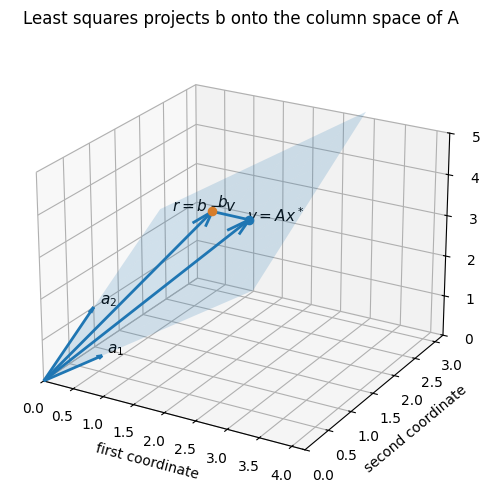

In [8]:
# Plot the column space plane, the target vector b,
# the closest reachable vector v, and the residual r.

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

setup_3d_axis(ax, "Least squares projects b onto the column space of A")

# Plane for the column space: z = x + y.
plane_x = np.linspace(0, 3.4, 12)
plane_y = np.linspace(0, 2.4, 12)
plane_X, plane_Y = np.meshgrid(plane_x, plane_y)
plane_Z = plane_X + plane_Y

ax.plot_surface(plane_X, plane_Y, plane_Z, alpha=0.18)

# Draw the two column directions.
origin = np.array([0, 0, 0])
draw_vector_3d(ax, origin, a1, "$a_1$")
draw_vector_3d(ax, origin, a2, "$a_2$", text_offset=(0.04, 0.08, 0.04))

# Draw b, its projection v, and the residual from v to b.
draw_vector_3d(ax, origin, b, "$b$", text_offset=(0.04, 0.04, 0.10))
draw_vector_3d(ax, origin, v, "$v = Ax^*$", text_offset=(0.04, -0.10, 0.04))
draw_vector_3d(ax, v, r, "$r = b - v$", text_offset=(-0.45, -0.25, 0.05))

# Mark the point v on the plane and b above the plane.
ax.scatter([v[0]], [v[1]], [v[2]], s=35)
ax.scatter([b[0]], [b[1]], [b[2]], s=35)

plt.show()

The plot is the main geometric idea.

The plane is $C(A)$, the column space of $A$.

The vector $\mathbf{b}$ is not on that plane, so $A\mathbf{x} = \mathbf{b}$ has no exact solution.

Least squares finds the point $\mathbf{v}$ on the plane that is closest to $\mathbf{b}$.

That is why:

$$
\mathbf{v}
=
A\mathbf{x}^{*}
=
\operatorname{proj}_{C(A)}(\mathbf{b})
$$

## The normal equations

The projection picture gives us an equation.

At the closest point, the residual is perpendicular to the columns of $A$:

$$
\mathbf{a}_1 \cdot \left(\mathbf{b} - A\mathbf{x}^{*}\right) = 0
$$

$$
\mathbf{a}_2 \cdot \left(\mathbf{b} - A\mathbf{x}^{*}\right) = 0
$$

Writing both dot products at once gives:

$$
A^T
\left(
\mathbf{b} - A\mathbf{x}^{*}
\right)
=
\mathbf{0}
$$

Rearranging gives the **normal equations**:

$$
A^T A\mathbf{x}^{*}
=
A^T\mathbf{b}
$$

This is not a new idea. It is the projection condition written in matrix form.

In [9]:
# Solve the normal equations directly.
#
# This is useful for understanding the maths.
# In real numerical code, np.linalg.lstsq is usually preferred.

left = A.T @ A
right = A.T @ b

x_from_normal_equations = np.linalg.solve(left, right)

print("A.T @ A:")
print(left)
print()
print_vector("A.T @ b", right)
print_vector("x from normal equations", x_from_normal_equations)
print_vector("x from np.linalg.lstsq", x_star)

A.T @ A:
[[2 1]
 [1 2]]

A.T @ b = [ 6.000,  5.000]
x from normal equations = [ 2.333,  1.333]
x from np.linalg.lstsq = [ 2.333,  1.333]


The normal equations produce the same $\mathbf{x}^{*}$.

That is because both approaches are finding the same thing:

> the point in $C(A)$ closest to $\mathbf{b}$.

## Connecting this back to line fitting

Line fitting is the same idea with different names.

For a straight-line model:

$$
\hat{y} = mx + c
$$

we build a design matrix $X$.

For x-values $1, 2, 3, 4$, the prediction equations are:

$$
\hat{y}_1 = 1m + 1c
$$

$$
\hat{y}_2 = 2m + 1c
$$

$$
\hat{y}_3 = 3m + 1c
$$

$$
\hat{y}_4 = 4m + 1c
$$

Stacked together:

$$
\hat{\mathbf{y}}
=
X\boldsymbol{\beta}
=
\begin{bmatrix}
1 & 1 \\
2 & 1 \\
3 & 1 \\
4 & 1
\end{bmatrix}
\begin{bmatrix}
m \\
c
\end{bmatrix}
$$

The first column controls the slope contribution.

The second column contains ones because the intercept $c$ is added once for every prediction.

So every possible prediction vector $\hat{\mathbf{y}}$ lives in the column space of $X$.

In [10]:
# Observed data.
x_data = np.array([1, 2, 3, 4])
y = np.array([2.2, 2.8, 4.5, 4.9])

# For the model:
#
#     predicted_y = m*x + c
#
# each row of the design matrix needs two values:
#
#     [x_value, 1]
#
# The x_value is multiplied by m.
# The 1 is multiplied by c, because the intercept is added once
# for every prediction.

# np.ones_like(x_data) creates an array of ones with the same shape as x_data.
intercept_column = np.ones_like(x_data)

# np.column_stack(...) puts arrays side by side as columns.
#
# This combines:
#
#     x_data           -> [1, 2, 3, 4]
#     intercept_column -> [1, 1, 1, 1]
#
# into:
#
#     [[1, 1],
#      [2, 1],
#      [3, 1],
#      [4, 1]]
X = np.column_stack([x_data, intercept_column])

print(X)

[[1 1]
 [2 1]
 [3 1]
 [4 1]]


In [11]:
# beta contains the parameters of the line:
#
#     beta[0] is m, the slope
#     beta[1] is c, the intercept

beta_star, *_ = np.linalg.lstsq(X, y, rcond=None)

y_hat = X @ beta_star
residual = y - y_hat

m, c = beta_star

print(f"m = {m:.3f}")
print(f"c = {c:.3f}")
print()
print_vector("observed y", y)
print_vector("predicted y_hat", y_hat)
print_vector("residual y - y_hat", residual)

m = 0.980
c = 1.150

observed y = [ 2.200,  2.800,  4.500,  4.900]
predicted y_hat = [ 2.130,  3.110,  4.090,  5.070]
residual y - y_hat = [ 0.070, -0.310,  0.410, -0.170]


In the line-fitting version:

$$
X\boldsymbol{\beta}^{*}
=
\operatorname{proj}_{C(X)}(\mathbf{y})
$$

That says:

> the best prediction vector is the projection of the observed data vector onto the column space of the design matrix.

The fitted line is the visible 2D version.

The projection happens in prediction-vector space.

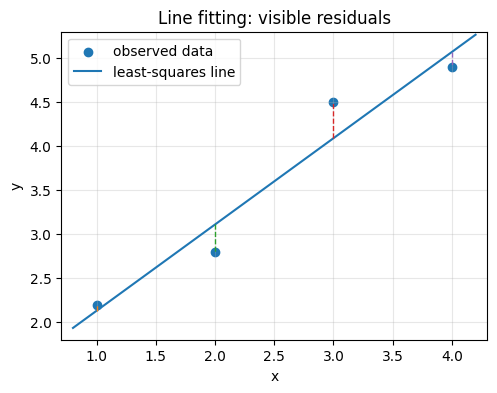

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4))

ax.scatter(x_data, y, label="observed data")

x_line = np.linspace(0.8, 4.2, 100)
y_line = m * x_line + c

ax.plot(x_line, y_line, label="least-squares line")

# Draw vertical residuals in the ordinary x-y plot.
for x_i, y_i, y_hat_i in zip(x_data, y, y_hat):
    ax.plot([x_i, x_i], [y_hat_i, y_i], linestyle="--", linewidth=1)

ax.set_title("Line fitting: visible residuals")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0.7, 4.3)
ax.set_ylim(1.8, 5.3)
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

This plot shows the line-fitting view: points, fitted line, and residuals.

The deeper linear-algebra view is:

- $\mathbf{y}$ is the data vector
- $X\boldsymbol{\beta}$ is a possible prediction vector
- $C(X)$ is the set of all prediction vectors the model can produce
- least squares chooses the prediction vector in $C(X)$ closest to $\mathbf{y}$

That closest prediction vector is a projection.

## Summary

A matrix-vector product can be read as a linear combination of the matrix columns:

$$
A\mathbf{x}
=
x_1\mathbf{a}_1
+
x_2\mathbf{a}_2
+
\cdots
+
x_k\mathbf{a}_k
$$

The column space $C(A)$ is the set of all vectors reachable by such combinations.

If $\mathbf{b}$ is in $C(A)$, then the exact system has a solution:

$$
A\mathbf{x} = \mathbf{b}
$$

If $\mathbf{b}$ is not in $C(A)$, then the exact system has no solution.

Least squares finds the reachable vector closest to $\mathbf{b}$:

$$
\mathbf{x}^{*}
=
\underset{\mathbf{x}}{\operatorname{argmin}}
\left\lVert
\mathbf{b} - A\mathbf{x}
\right\rVert^2
$$

The closest reachable vector is:

$$
A\mathbf{x}^{*}
$$

and that vector is the projection of $\mathbf{b}$ onto the column space of $A$:

$$
A\mathbf{x}^{*}
=
\operatorname{proj}_{C(A)}(\mathbf{b})
$$

The leftover residual is perpendicular to the column space:

$$
A^T
\left(
\mathbf{b} - A\mathbf{x}^{*}
\right)
=
\mathbf{0}
$$

That is why least squares is a projection problem.